In [41]:
import pandas as pd
import numpy as np
import networkx as nx
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import networkx.algorithms.community as nx_comm

# 1. Load Data & Rename Columns to Short IDs (T01, E02, etc.)
df = pd.read_csv("Survey_Results_UC.csv")

# Create a mapping from full question text to short ID (e.g., 'T01. ...' -> 'T01')
col_mapping = {col: col[:3] for col in df.columns if col != 'id. Response ID'}
df = df.rename(columns=col_mapping)

# Drop the ID column
df = df.drop(columns=['id. Response ID'])

# Extract Metadata using the newly mapped short IDs
questions = df.columns.tolist()
metadata = []
category_map = {'T': 'Technology', 'E': 'Education', 'S': 'Social/Ethics', 'V': 'Environment'}

# Re-read to get the original full text for metadata
original_df = pd.read_csv("Survey_Results_UC.csv")
for col in original_df.columns:
    if col != 'id. Response ID':
        q_id = col[:3]
        cat = category_map.get(q_id[0], 'Unknown')
        text = col[5:] 
        metadata.append({'question_id': q_id, 'category': cat, 'question_text': text})

df_meta = pd.DataFrame(metadata)

# 2. Preprocess Likert Data
likert_mapping = {'Strongly Disagree': 1, 'Disagree': 2, 'Neutral': 3, 'Agree': 4, 'Strongly Agree': 5, 'No Comments': np.nan}
for col in questions:
    df[col] = df[col].map(likert_mapping)

# Compute Spearman correlation
corr_spearman = df.corr(method='spearman')

print("Data loaded, cleaned, and properly mapped to short IDs.")

Data loaded, cleaned, and properly mapped to short IDs.


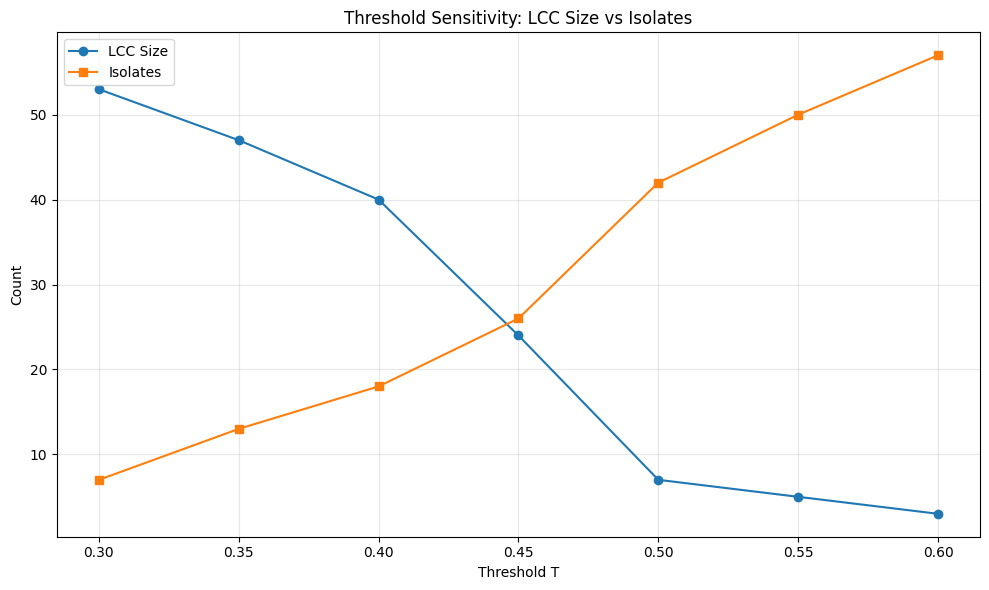

### Threshold Sensitivity Analysis


,Threshold,Edges,Density,Avg Degree,Components,LCC Size,Isolates,Clustering
0,0.30,322,0.1819,10.7333,8,53,7,0.5508
1,0.35,188,0.1062,6.2667,14,47,13,0.4410
2,0.40,91,0.0514,3.0333,20,40,18,0.2826
3,0.45,43,0.0243,1.4333,32,24,26,0.2558
4,0.50,13,0.0073,0.4333,48,7,42,0.3000
5,0.55,7,0.0040,0.2333,53,5,50,0.0000
6,0.60,2,0.0011,0.0667,58,3,57,0.0000



### Graph Constructed at Selected Working Threshold (T=0.4)
Largest Connected Component (LCC): 40 nodes, 90 edges

### Louvain Robustness Analysis


,Seed,Communities,Modularity
0,0,6,0.3580
1,1,5,0.3671
2,2,6,0.3317
3,3,5,0.3560
4,4,5,0.3741
5,42,6,0.3676


In [42]:
import os
import pandas as pd
import numpy as np
import networkx as nx
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import networkx.algorithms.community as nx_comm

# Ensure output folder exists for report-ready figures
os.makedirs('figures', exist_ok=True)

# 3. Expanded Threshold Sensitivity Analysis
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
results = []
N = len(questions)

for t in thresholds:
    adj = (corr_spearman > t).astype(int)
    np.fill_diagonal(adj.values, 0)
    G = nx.from_pandas_adjacency(adj)
    
    edges = G.number_of_edges()
    density = (2 * edges) / (N * (N - 1)) if N > 1 else 0
    
    if edges > 0:
        avg_deg = sum(dict(G.degree()).values()) / N
        components = sorted(nx.connected_components(G), key=len, reverse=True)
        num_comps = len(components)
        lcc_size = len(components[0])
        isolates = len([c for c in components if len(c) == 1])
        clustering = nx.transitivity(G)
    else:
        avg_deg, num_comps, lcc_size, isolates, clustering = 0, N, 0, N, 0
        
    results.append({
        'Threshold': t,
        'Edges': edges,
        'Density': density,
        'Avg Degree': avg_deg,
        'Components': num_comps,
        'LCC Size': lcc_size,
        'Isolates': isolates,
        'Clustering': clustering
    })

df_results = pd.DataFrame(results)

# Optional plot saved to figures/ for the report
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_results['Threshold'], df_results['LCC Size'], marker='o', label='LCC Size')
ax.plot(df_results['Threshold'], df_results['Isolates'], marker='s', label='Isolates')
ax.set_title('Threshold Sensitivity: LCC Size vs Isolates')
ax.set_xlabel('Threshold T')
ax.set_ylabel('Count')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig('figures/threshold_sensitivity.png', dpi=220, bbox_inches='tight')
plt.show()
plt.close(fig)

# 4. Generate Final T=0.4 Graph & Extract Largest Connected Component (LCC)
FINAL_THRESHOLD = 0.4

# Create a weighted adjacency matrix, preserving actual correlation values > FINAL_THRESHOLD
weighted_adj = corr_spearman.where(corr_spearman > FINAL_THRESHOLD, 0)
np.fill_diagonal(weighted_adj.values, 0)

G_weighted = nx.from_pandas_adjacency(weighted_adj)

# Extract components
components = sorted(nx.connected_components(G_weighted), key=len, reverse=True)
lcc_nodes = components[0]
pair_nodes = components[1]
isolated_nodes = [list(c)[0] for c in components if len(c) == 1]

# Subgraph for Community Detection
G_lcc = G_weighted.subgraph(lcc_nodes).copy()

# 5. Robustness Analysis of Louvain
seeds = [0, 1, 2, 3, 4, 42]
robustness_results = []

for s in seeds:
    comms = nx_comm.louvain_communities(G_lcc, weight='weight', seed=s)
    mod = nx_comm.modularity(G_lcc, comms, weight='weight')
    robustness_results.append({'Seed': s, 'Communities': len(comms), 'Modularity': mod})

df_robustness = pd.DataFrame(robustness_results)

# Map final communities for Seed=42
final_communities = nx_comm.louvain_communities(G_lcc, weight='weight', seed=42)
community_map = {}
for i, comm in enumerate(final_communities):
    for node in comm:
        community_map[node] = i + 1

nx.set_node_attributes(G_lcc, community_map, 'community')

print("### Threshold Sensitivity Analysis")
display(df_results.round(4))
print(f"\n### Graph Constructed at Selected Working Threshold (T={FINAL_THRESHOLD})")
print(f"Largest Connected Component (LCC): {G_lcc.number_of_nodes()} nodes, {G_lcc.number_of_edges()} edges")
print("\n### Louvain Robustness Analysis")
display(df_robustness.round(4))


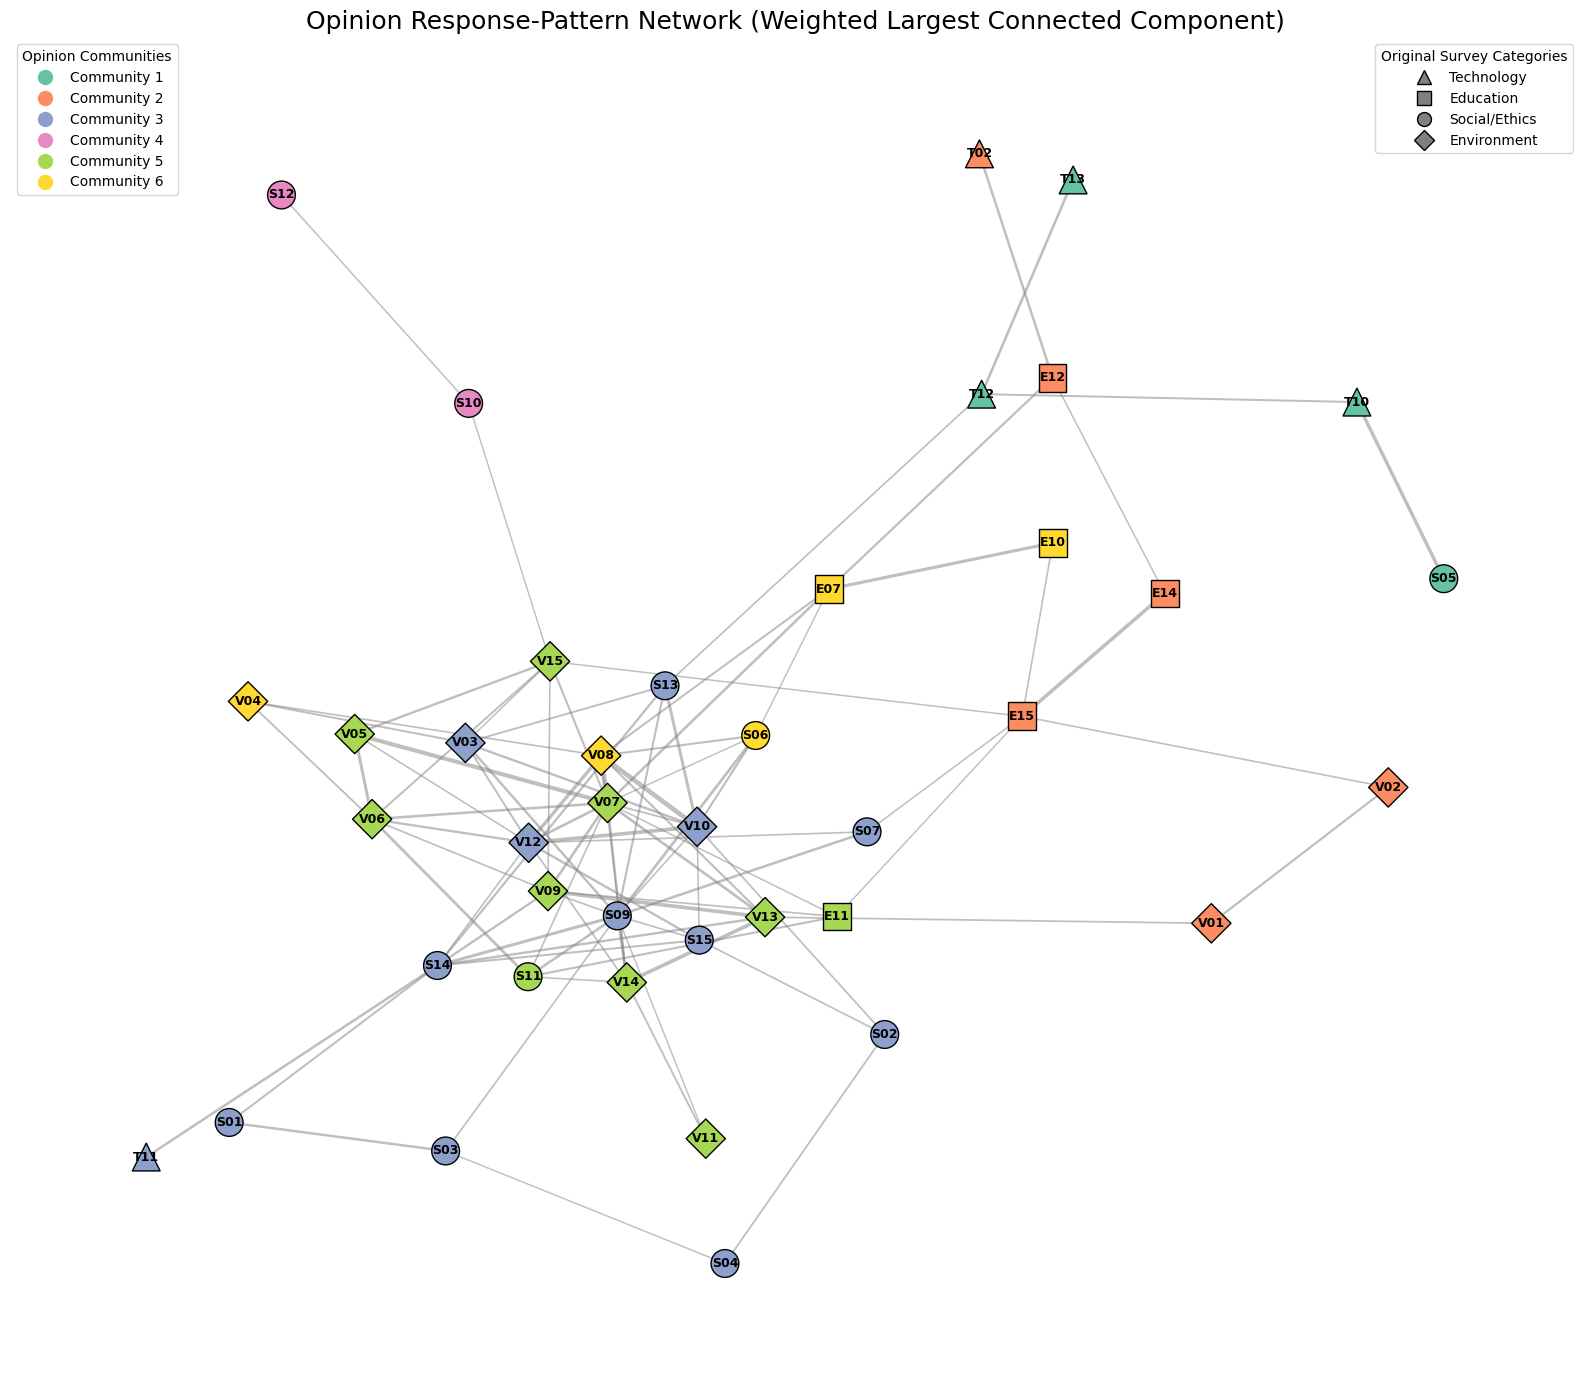

In [43]:
# Visualization
os.makedirs('figures', exist_ok=True)

plt.figure(figsize=(16, 14))
pos = nx.spring_layout(G_lcc, weight='weight', k=0.35, seed=42)

category_shapes = {'Technology': '^', 'Education': 's', 'Social/Ethics': 'o', 'Environment': 'D'}
cat_to_node = df_meta.set_index('question_id')['category'].to_dict()

cmap = plt.get_cmap('Set2')
colors = [cmap(i) for i in range(len(final_communities))]

for cat, shape in category_shapes.items():
    nodelist = [n for n in G_lcc.nodes() if cat_to_node.get(n) == cat]
    if not nodelist: continue
    node_colors = [colors[community_map[n] - 1] for n in nodelist]
    nx.draw_networkx_nodes(G_lcc, pos, nodelist=nodelist, node_shape=shape, 
                           node_color=node_colors, node_size=400, edgecolors='black')

edge_weights = [G_lcc[u][v]['weight'] for u, v in G_lcc.edges()]
scaled_widths = [(w - 0.4) * 10 + 1 for w in edge_weights] 
nx.draw_networkx_edges(G_lcc, pos, width=scaled_widths, alpha=0.5, edge_color='gray')
nx.draw_networkx_labels(G_lcc, pos, font_size=9, font_weight='bold')

color_handles = [mlines.Line2D([], [], color=colors[i], marker='o', linestyle='None', 
                               markersize=10, label=f'Community {i+1}') for i in range(len(final_communities))]
shape_handles = [mlines.Line2D([], [], color='white', marker=shape, markerfacecolor='gray', 
                               markeredgecolor='black', markersize=10, label=cat) 
                 for cat, shape in category_shapes.items()]

legend1 = plt.legend(handles=color_handles, title='Opinion Communities', loc='upper left', fontsize=10)
plt.gca().add_artist(legend1)
plt.legend(handles=shape_handles, title='Original Survey Categories', loc='upper right', fontsize=10)

plt.title('Opinion Response-Pattern Network (Weighted Largest Connected Component)', fontsize=18)
plt.axis('off')
plt.tight_layout()
plt.savefig('figures/opinion_similarity_network.png', dpi=220, bbox_inches='tight')
plt.show()


In [44]:
# Centrality Analysis

degree = dict(G_lcc.degree())
strength = dict(G_lcc.degree(weight='weight'))
betweenness = nx.betweenness_centrality(G_lcc, normalized=True)
closeness = nx.closeness_centrality(G_lcc)
eigenvector = nx.eigenvector_centrality(G_lcc, weight='weight', max_iter=2000)
clustering = nx.clustering(G_lcc, weight='weight')

metrics_df = pd.DataFrame({
    'question_id': list(G_lcc.nodes()),
    'degree': [degree[n] for n in G_lcc.nodes()],
    'strength': [strength[n] for n in G_lcc.nodes()],
    'betweenness': [betweenness[n] for n in G_lcc.nodes()],
    'closeness': [closeness[n] for n in G_lcc.nodes()],
    'eigenvector': [eigenvector[n] for n in G_lcc.nodes()],
    'clustering': [clustering[n] for n in G_lcc.nodes()]
}).merge(df_meta, on='question_id')

print("### Top 10 Structural Bridges (Betweenness Centrality)")
display(metrics_df.sort_values('betweenness', ascending=False)[['question_id', 'category', 'betweenness', 'strength', 'question_text']].head(10))

print("### Top 10 Core Consensus Opinions (Eigenvector Centrality)")
display(metrics_df.sort_values('eigenvector', ascending=False)[['question_id', 'category', 'eigenvector', 'closeness', 'question_text']].head(10))

### Top 10 Structural Bridges (Betweenness Centrality)


,question_id,category,betweenness,strength,question_text
18,S09,Social/Ethics,0.201339,5.440479,Universities should promote an inclusive envir...
22,S13,Social/Ethics,0.191870,2.295909,Critical evaluation of online information shou...
3,T12,Technology,0.148448,1.360031,Governments should introduce stricter regulati...
39,V15,Environment,0.145542,3.007228,Current generations have a responsibility to p...
31,V07,Environment,0.142727,6.280221,Protecting biodiversity is essential for long-...
23,S14,Social/Ethics,0.132689,3.723960,Leaders should prioritize ethical decision-mak...
10,E15,Education,0.115301,2.616441,Continuous learning and skill development are ...
5,E07,Education,0.114180,2.327095,Publishing research before graduation should b...
34,V10,Environment,0.112241,4.334952,Consumers should consider environmental impact...
27,V03,Environment,0.072855,2.684109,Individuals should actively reduce their perso...


### Top 10 Core Consensus Opinions (Eigenvector Centrality)


,question_id,category,eigenvector,closeness,question_text
31,V07,Environment,0.404135,0.481481,Protecting biodiversity is essential for long-...
36,V12,Environment,0.321436,0.443182,Environmental sustainability should be integra...
32,V08,Environment,0.301822,0.438202,Universities should adopt environmentally sust...
34,V10,Environment,0.296747,0.443182,Consumers should consider environmental impact...
18,S09,Social/Ethics,0.266681,0.481481,Universities should promote an inclusive envir...
38,V14,Environment,0.235633,0.414894,International cooperation is necessary to effe...
33,V09,Environment,0.219660,0.443182,Products should be designed to encourage reuse...
30,V06,Environment,0.218296,0.393939,Water conservation should be a priority in hou...
37,V13,Environment,0.209412,0.406250,Companies should be held accountable for the e...
23,S14,Social/Ethics,0.190646,0.428571,Leaders should prioritize ethical decision-mak...


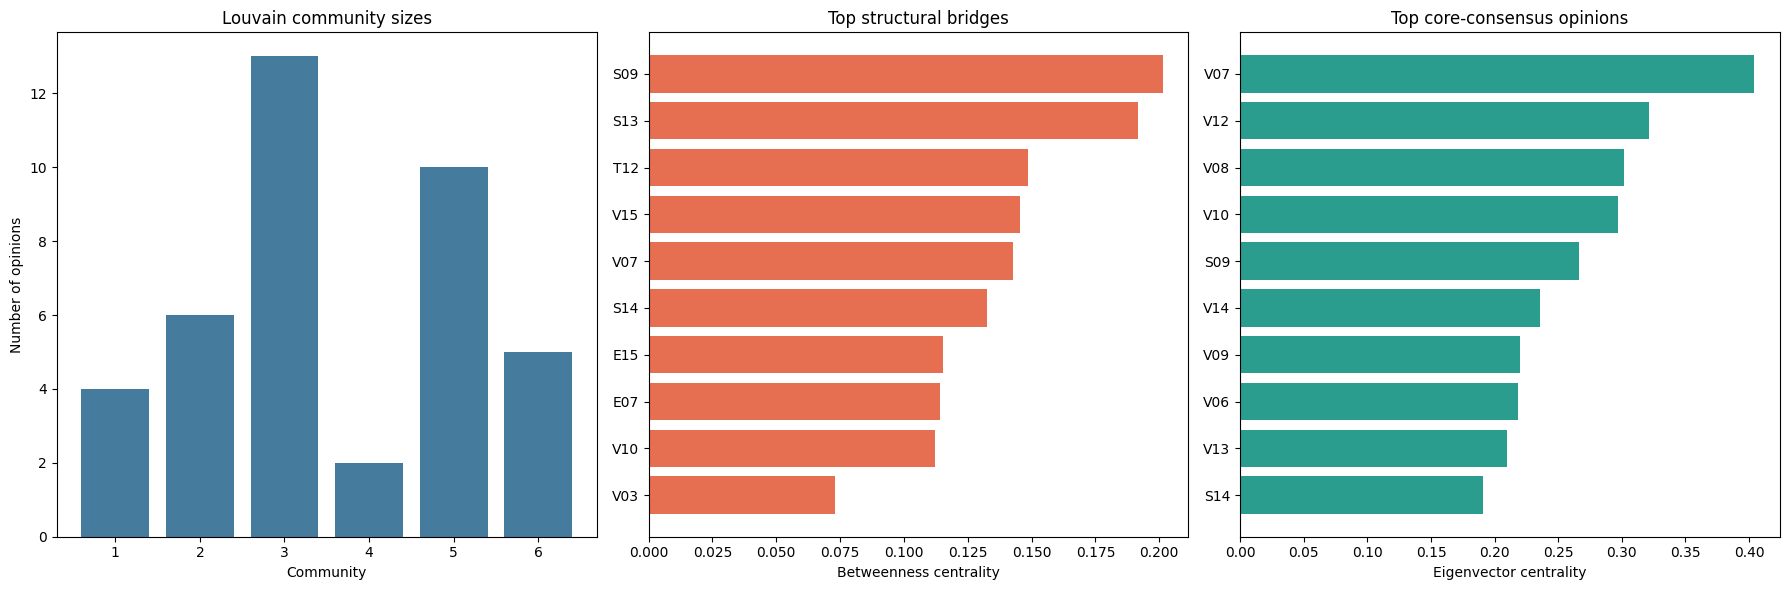

In [45]:
# Report-ready centrality and community summary plot
os.makedirs('figures', exist_ok=True)
community_sizes = pd.Series(community_map).value_counts().sort_index()
top_bridge = metrics_df.sort_values('betweenness', ascending=False).head(10).sort_values('betweenness')
top_core = metrics_df.sort_values('eigenvector', ascending=False).head(10).sort_values('eigenvector')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].bar(community_sizes.index.astype(str), community_sizes.values, color='#457b9d')
axes[0].set_title('Louvain community sizes')
axes[0].set_xlabel('Community')
axes[0].set_ylabel('Number of opinions')

axes[1].barh(top_bridge['question_id'], top_bridge['betweenness'], color='#e76f51')
axes[1].set_title('Top structural bridges')
axes[1].set_xlabel('Betweenness centrality')

axes[2].barh(top_core['question_id'], top_core['eigenvector'], color='#2a9d8f')
axes[2].set_title('Top core-consensus opinions')
axes[2].set_xlabel('Eigenvector centrality')

fig.tight_layout()
fig.savefig('figures/centrality_community_summary.png', dpi=220, bbox_inches='tight')
plt.show()


# Cell: Global Metrics & Structural Distributions


### Global Network Topology (LCC)


,Metric,Value
0,LCC Nodes,40.0000
1,LCC Edges,90.0000
2,Average Degree,4.5000
3,Graph Density,0.1154
4,Diameter,8.0000
5,Avg Shortest Path Length,2.9564
6,Global Transitivity,0.2826
7,Mean Local Clustering,0.1468


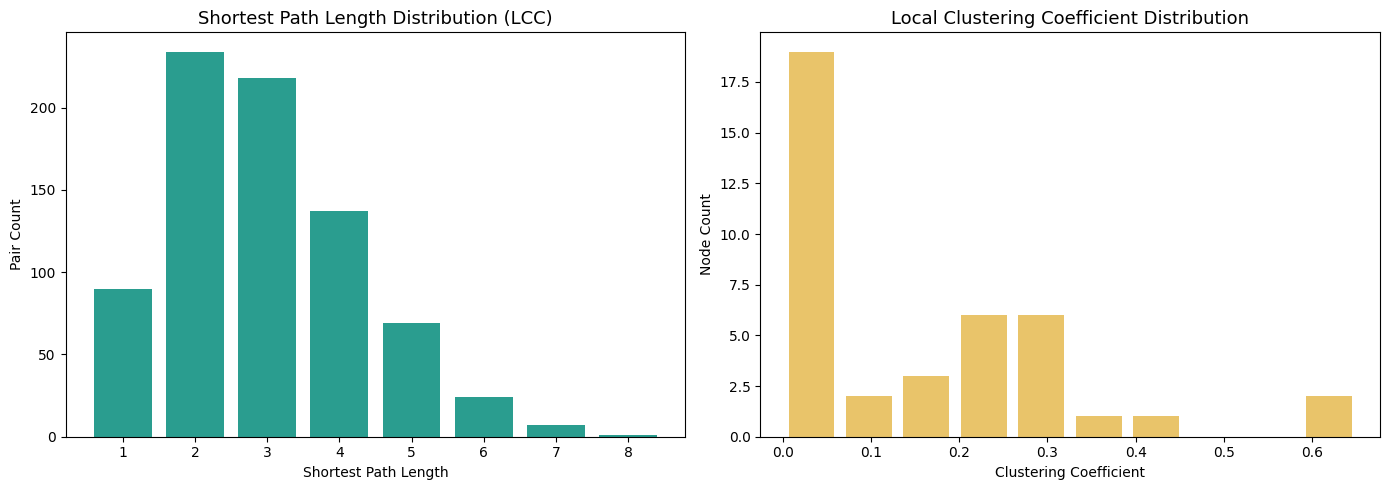

In [46]:
os.makedirs('figures', exist_ok=True)
shortest_paths = dict(nx.all_pairs_shortest_path_length(G_lcc))
path_lengths = [
    d for src, targets in shortest_paths.items() for tgt, d in targets.items() if src < tgt
]

global_summary = pd.DataFrame({
    'Metric': [
        'LCC Nodes', 'LCC Edges', 'Average Degree', 'Graph Density',
        'Diameter', 'Avg Shortest Path Length', 'Global Transitivity', 'Mean Local Clustering'
    ],
    'Value': [
        G_lcc.number_of_nodes(),
        G_lcc.number_of_edges(),
        np.mean(list(degree.values())),
        nx.density(G_lcc),
        nx.diameter(G_lcc),
        nx.average_shortest_path_length(G_lcc),
        nx.transitivity(G_lcc),
        np.mean(list(clustering.values()))
    ]
})
print("### Global Network Topology (LCC)")
display(global_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(path_lengths, bins=range(1, max(path_lengths) + 2), align='left', rwidth=0.8, color='#2a9d8f')
axes[0].set_title('Shortest Path Length Distribution (LCC)', fontsize=13)
axes[0].set_xlabel('Shortest Path Length')
axes[0].set_ylabel('Pair Count')

axes[1].hist(list(clustering.values()), bins=10, rwidth=0.8, color='#e9c46a')
axes[1].set_title('Local Clustering Coefficient Distribution', fontsize=13)
axes[1].set_xlabel('Clustering Coefficient')
axes[1].set_ylabel('Node Count')
plt.tight_layout()
plt.savefig('figures/global_topology_histograms.png', dpi=220, bbox_inches='tight')
plt.show()


### Within vs Cross-Domain Edge Distribution


,count,mean_weight,share
relation,,,
Cross-Domain,34,0.4427,0.3778
Within-Domain,56,0.4704,0.6222


### Domain Mixing Matrix


,Technology,Education,Social/Ethics,Environment
Technology,2,1,3,0
Education,1,6,3,6
Social/Ethics,3,3,15,21
Environment,0,6,21,33


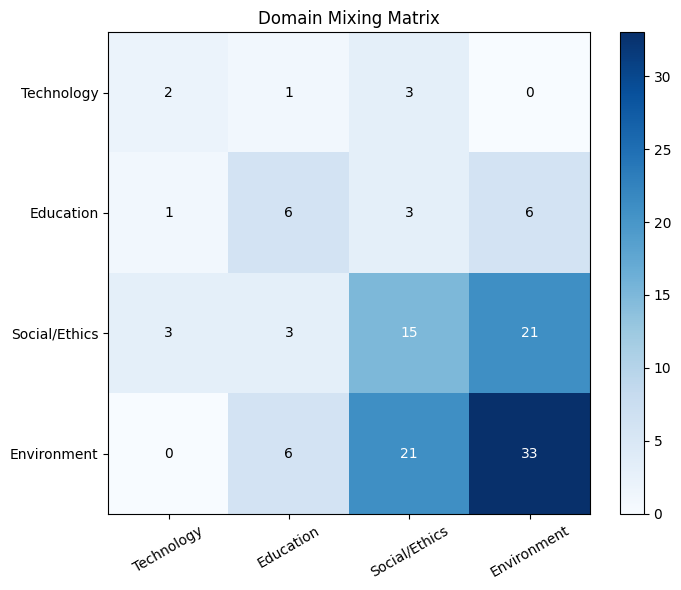

In [47]:
# Cell: Domain Interaction & Mixing Matrix
edge_data = []
for u, v, d in G_lcc.edges(data=True):
    cat_u = cat_to_node[u]
    cat_v = cat_to_node[v]
    edge_data.append({
        'u': u, 'v': v, 'cat_u': cat_u, 'cat_v': cat_v,
        'relation': 'Within-Domain' if cat_u == cat_v else 'Cross-Domain',
        'weight': d['weight']
    })
df_edges = pd.DataFrame(edge_data)

edge_summary = df_edges.groupby('relation').agg(
    count=('weight', 'size'),
    mean_weight=('weight', 'mean')
)
edge_summary['share'] = edge_summary['count'] / len(df_edges)
print("### Within vs Cross-Domain Edge Distribution")
display(edge_summary.round(4))

cats = list(category_shapes.keys())
mixing_matrix = pd.DataFrame(0, index=cats, columns=cats)
for _, row in df_edges.iterrows():
    mixing_matrix.loc[row['cat_u'], row['cat_v']] += 1
    if row['cat_u'] != row['cat_v']:
        mixing_matrix.loc[row['cat_v'], row['cat_u']] += 1

print("### Domain Mixing Matrix")
display(mixing_matrix)

# Save and display domain mixing plot for report
fig, ax = plt.subplots(figsize=(8, 6))
img = ax.imshow(mixing_matrix.values, cmap='Blues')
ax.set_xticks(range(len(cats)))
ax.set_yticks(range(len(cats)))
ax.set_xticklabels(cats, rotation=30)
ax.set_yticklabels(cats)
for i in range(mixing_matrix.shape[0]):
    for j in range(mixing_matrix.shape[1]):
        val = int(mixing_matrix.iloc[i, j])
        ax.text(j, i, val, ha='center', va='center', color='black' if val < 10 else 'white')
ax.set_title('Domain Mixing Matrix')
fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig('figures/domain_mixing_matrix.png', dpi=220, bbox_inches='tight')
plt.show()
plt.close(fig)


## 4. Semantic Community Breakdown & Substantive Synthesis

* **Community 1 (4 items: T10, T12, T13, S05):** *Data Privacy, Cybersecurity & AI Governance* (Cross-cutting Tech & Ethics).
* **Community 2 (6 items: E12, E14, E15, T02, V01, V02):** *Institutional Adaptation, AI in Education & Renewable Energy Policy*.
* **Community 3 (13 items: S01, S02, S03, S04, S07, S09, S13, S14, S15, V03, V10, V12, T11):** *Social Responsibility, Corporate Accountability & Everyday Sustainability*.
* **Community 4 (2 items: S10, S12):** *Evidence-Based Policy & Youth Civic Engagement*.
* **Community 5 (10 items: V05, V06, V07, V09, V11, V13, V14, V15, E11, S11):** *Ecological Conservation, Global Treaties & Circular Economy*.
* **Community 6 (5 items: E07, E10, V04, V08, S06):** *Higher Education Innovation & Sustainable Campus Operations*.

## 5. Substantive Analysis of the Isolated Pair & 18 Isolates

* **The Isolated Pair (`E05`, `E06`):** Focuses specifically on mandatory undergraduate research and interdisciplinary courses—a localized curricular sub-theme distinct from overarching societal/environmental values.
* **The 18 Isolates:** Noticeably dominated by specific Technology topics (`T01`, `T04`, `T06`, `T08`, `T09`, etc.) and exam policies (`E02`, `E03`). These reflect questions where class sentiment was either highly polarized or simply lacked uniform covariance with broad sustainability and institutional ethics trends.